In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

In [19]:
merged_df

,lss_RMSE-mean,lss_RMSE-std,lss_NLL-mean,lss_NLL-std,lss_CRPS-mean,lss_CRPS-std,lss_CRPS-calibration-mean,lss_CRPS-calibration-std,lss_CRPS-sharpness-mean,lss_CRPS-sharpness-std,...,ngb_CRPS-std,ngb_CRPS-calibration-mean,ngb_CRPS-calibration-std,ngb_CRPS-sharpness-mean,ngb_CRPS-sharpness-std,ngb_time,rep_RMSE-mean,rep_RMSE-std,rep_NLL-mean,rep_NLL-std
dset,,,,,,,,,,,,,,,,,,,,,
Boston Housing,3.159341,0.843938,2.884646,0.580876,1.677238,0.350879,2.667563,0.373571,0.990325,0.079321,...,0.204121,2.124853,0.202413,0.533748,0.159700,52.214740,2.94,0.53,2.43,0.15
Concrete Compression Strength,4.666600,0.758023,4.279176,1.025372,2.472233,0.388131,3.604114,0.408740,1.131880,0.042308,...,0.257777,3.917589,0.247328,1.454618,0.064469,53.668497,5.06,0.61,3.04,0.17
Energy Efficiency,0.723530,0.158877,0.788992,0.258014,0.339813,0.062131,0.638922,0.108949,0.299109,0.060664,...,0.021389,0.427764,0.027651,0.194677,0.011025,61.634734,0.46,0.06,0.60,0.45
Combined Cycle Power Plant,3.370299,0.195621,2.735810,0.138194,1.793519,0.066130,3.215052,0.070574,1.421533,0.017146,...,0.072699,3.643375,0.070158,1.697245,0.012696,132.850012,3.79,0.18,2.79,0.11
Protein Structure,3.856708,0.019934,2.790060,0.039908,2.024444,0.012898,3.483603,0.018273,1.459159,0.007374,...,0.029102,4.738425,0.057950,2.275355,0.031616,1173.968657,4.33,0.03,2.81,0.03
Wine Quality Red,0.626615,0.038979,0.914587,0.068385,0.346017,0.021096,0.686006,0.035481,0.339989,0.022577,...,0.023536,0.599395,0.044409,0.257786,0.030988,62.596604,0.63,0.04,0.91,0.06
Kin8nm,0.247955,0.004963,0.002296,0.013209,0.141309,0.002558,0.311338,0.003650,0.170029,0.001459,...,0.002346,0.169589,0.002764,0.075608,0.001070,228.306825,0.16,0.00,-0.49,0.02
Yacht Hydrodynamics,3.498071,1.194186,1.188552,0.799702,1.146246,0.487149,1.888943,0.681009,0.742697,0.210091,...,0.149016,0.512357,0.544721,0.224515,0.407918,51.050431,0.50,0.20,0.20,0.26
Naval Propulsion,0.213284,0.000341,-0.032459,0.001141,0.129607,0.000403,0.297578,0.000509,0.167971,0.000336,...,0.000038,0.002108,0.000067,0.000982,0.000032,337.821525,0.00,0.00,-5.34,0.04


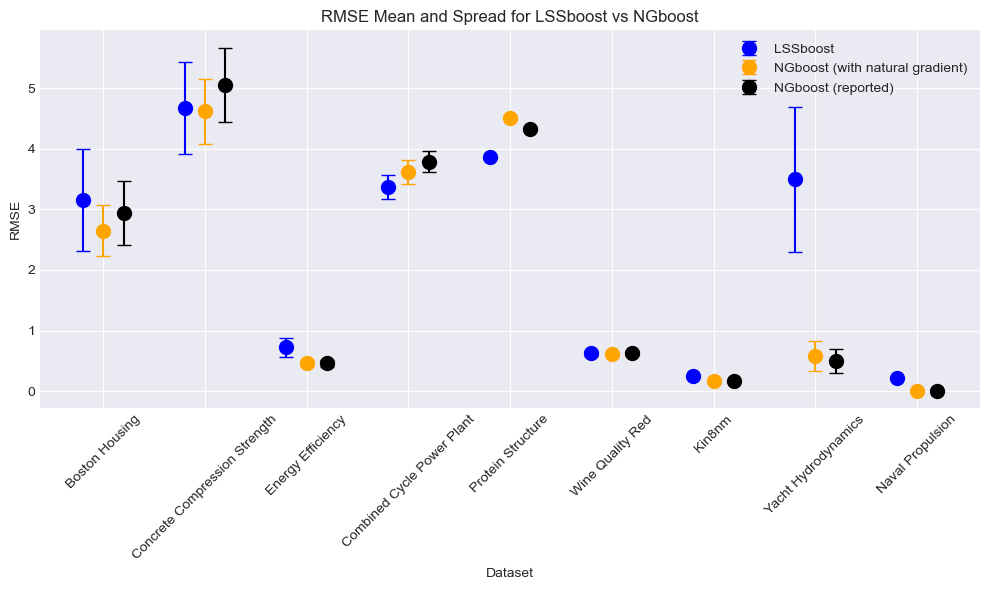

In [18]:
df_lssboost = pd.read_csv('results/LSSboost_natural.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_crps_calibration_sharpness.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_crps_calibration_sharpness.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_RMSE-mean']
stds_lssboost = merged_df['lss_RMSE-std']
means_lssboost_nonatural = merged_df['lss_nonatural_RMSE-mean']
stds_lssboost_nonatural = merged_df['lss_nonatural_RMSE-std']
means_ngboost = merged_df['ngb_RMSE-mean']
stds_ngboost = merged_df['ngb_RMSE-std']
means_rep_ngboost = merged_df['rep_RMSE-mean']
stds_rep_ngboost = merged_df['rep_RMSE-std']


x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
# Calculate positions for each group
positions_lssboost = x - width
positions_ngboost = x
positions_rep_ngboost = x + width
positions_lssboost_nonatural = x + 2*width
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (with natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
plt.errorbar(positions_rep_ngboost, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Mean and Spread for LSSboost vs NGboost')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('RMSE_evaluation_probdist.png')
plt.show()


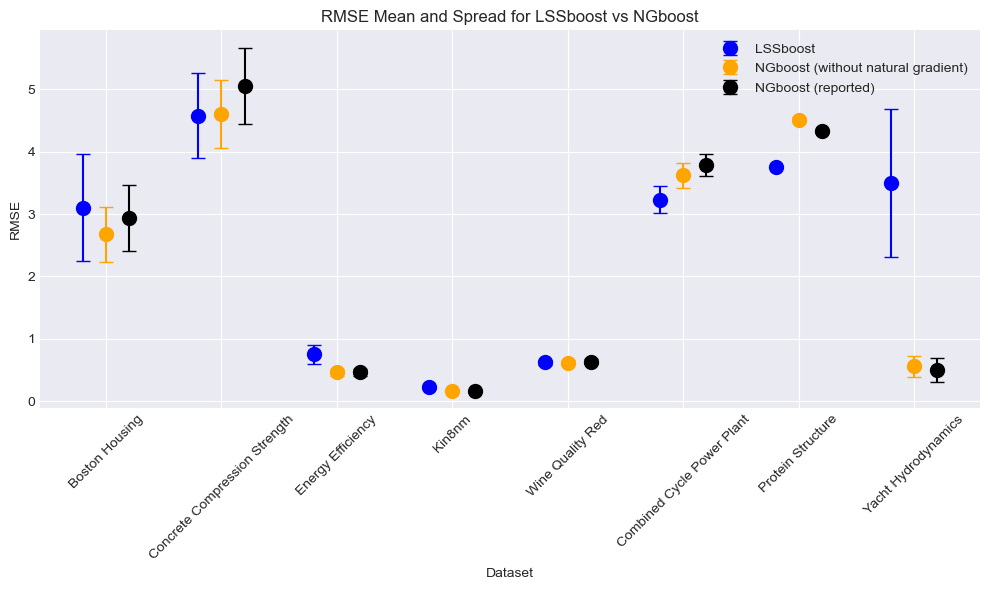

In [6]:
df_lssboost = pd.read_csv('results/LSSboost_natural.csv', index_col=['dset']).iloc[:-1,:]
df_ngboost = pd.read_csv('results/NGboost_reproduced.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset']).iloc[:-1,:]

df_lssboost = df_lssboost.add_prefix('lss_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_RMSE-mean']
stds_lssboost = merged_df['lss_RMSE-std']
means_ngboost = merged_df['ngb_RMSE-mean']
stds_ngboost = merged_df['ngb_RMSE-std']
means_rep_ngboost = merged_df['rep_RMSE-mean']
stds_rep_ngboost = merged_df['rep_RMSE-std']

x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
# Calculate positions for each group
positions_lssboost = x - width
positions_ngboost = x
positions_rep_ngboost = x + width
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
plt.errorbar(positions_rep_ngboost, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Mean and Spread for LSSboost vs NGboost')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('RMSE_evaluation_probdist.png')
plt.show()


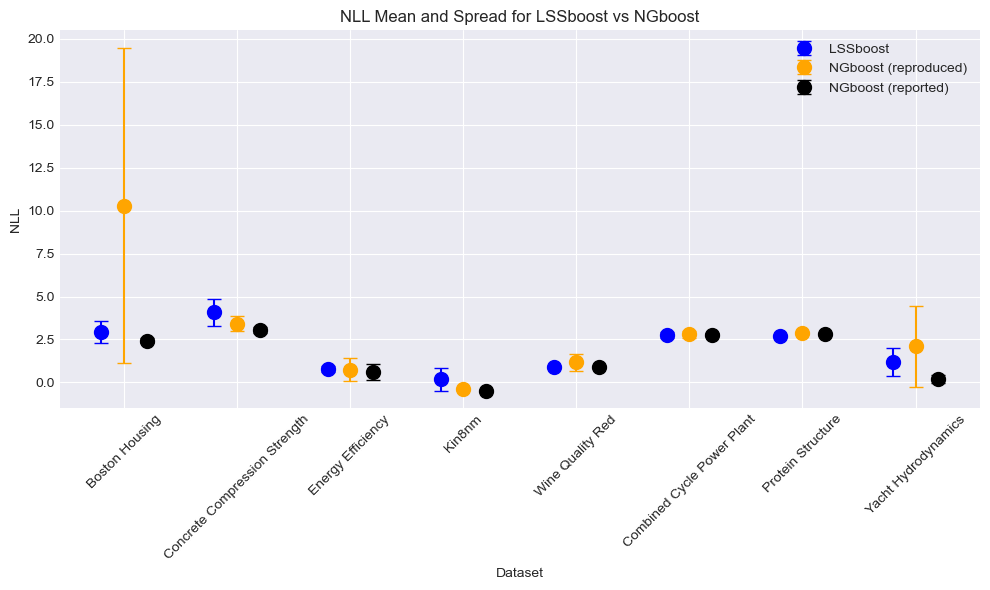

In [8]:
df_lssboost = pd.read_csv('results/LSSboost_natural.csv', index_col=['dset']).iloc[:-1,:]
df_ngboost = pd.read_csv('results/NGboost_reproduced.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset']).iloc[:-1,:]

df_lssboost = df_lssboost.add_prefix('lss_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_NLL-mean']
stds_lssboost = merged_df['lss_NLL-std']
means_ngboost = merged_df['ngb_NLL-mean']
stds_ngboost = merged_df['ngb_NLL-std']
means_rep_ngboost = merged_df['rep_NLL-mean']
stds_rep_ngboost = merged_df['rep_NLL-std']

x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
# Calculate positions for each group
positions_lssboost = x - width
positions_ngboost = x
positions_rep_ngboost = x + width
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (reproduced)', markersize=dot_size)

# Plotting NGboost reported means with error bars
plt.errorbar(positions_rep_ngboost, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('NLL')
ax.set_title('NLL Mean and Spread for LSSboost vs NGboost')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('NLL_evaluation_probdist.png')
plt.show()
